# 03 — nn.Module: Building Neural Networks

**Project:** AutoGrader  
**Purpose:** Build, train, and evaluate a neural network using PyTorch's nn.Module  
**Covers:** nn.Module, layers, forward pass, loss functions, optimizers, full training loop

---

## What is nn.Module?

In notebook 02, you manually defined weights as tensors and updated them yourself.  
That works for 2 weights — not for 2 million.

`nn.Module` is PyTorch's base class for every neural network. It gives you:
- A clean way to define layers as a Python class
- Automatic parameter tracking (no manual `requires_grad`)
- One-line calls to move the whole model to GPU
- Save/load model weights

Think of it like this: tensors are bricks, autograd is the physics, and `nn.Module` is the blueprint.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)  # reproducibility
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.5.1


---
## Section 1 — Your first nn.Module

In [2]:
# The minimal structure every PyTorch model follows
# Two rules:
#   1. Inherit from nn.Module
#   2. Define forward() — what happens when data flows through

class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()          # always call this first
        self.layer1 = nn.Linear(4, 8)   # input: 4 features → output: 8 neurons
        self.layer2 = nn.Linear(8, 1)   # input: 8 neurons  → output: 1 value
        self.relu   = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))   # layer1 → activation
        x = self.layer2(x)              # layer2 (no activation on output)
        return x

model = TinyNet()
print(model)  # shows architecture

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")
# layer1: 4*8 weights + 8 biases = 40
# layer2: 8*1 weights + 1 bias   = 9
# Total = 49

TinyNet(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 49


In [3]:
# --- Running a forward pass ---
# You never call forward() directly — you call the model like a function

x = torch.randn(1, 4)   # 1 sample, 4 features
output = model(x)        # internally calls forward(x)

print("Input shape: ", x.shape)       # [1, 4]
print("Output shape:", output.shape)  # [1, 1]
print("Output value:", output.item())

Input shape:  torch.Size([1, 4])
Output shape: torch.Size([1, 1])
Output value: 0.014952853322029114


In [4]:
# --- Batch processing — the real way ---
# In practice you pass multiple samples at once (a batch)

batch = torch.randn(32, 4)   # 32 samples, 4 features each
outputs = model(batch)

print("Batch input shape: ", batch.shape)    # [32, 4]
print("Batch output shape:", outputs.shape)  # [32, 1]
# The model processes all 32 samples simultaneously — that's why GPUs help

Batch input shape:  torch.Size([32, 4])
Batch output shape: torch.Size([32, 1])


---
## Section 2 — Common Layers

In [5]:
# --- nn.Linear: the workhorse ---
# Does: output = input @ weight.T + bias
# That's it. Every "dense" or "fully connected" layer is this.

linear = nn.Linear(in_features=3, out_features=5)
x = torch.randn(2, 3)   # 2 samples, 3 features
out = linear(x)
print("nn.Linear output shape:", out.shape)  # [2, 5]
print("Weight shape:", linear.weight.shape)  # [5, 3]
print("Bias shape:  ", linear.bias.shape)    # [5]

nn.Linear output shape: torch.Size([2, 5])
Weight shape: torch.Size([5, 3])
Bias shape:   torch.Size([5])


In [6]:
# --- Activation functions ---
# Without activations, stacking linear layers is pointless
# (linear of linear is still just linear)
# Activations add non-linearity — the ability to learn complex patterns

x = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])

print("Input:  ", x.numpy())
print("ReLU:   ", nn.ReLU()(x).numpy())      # max(0, x) — most common
print("Sigmoid:", nn.Sigmoid()(x).numpy())   # squash to [0,1] — use for binary output
print("Tanh:   ", nn.Tanh()(x).numpy())      # squash to [-1,1]
print("GELU:   ", nn.GELU()(x).numpy())      # used in transformers (BERT, GPT)

# Rule of thumb:
# Hidden layers  → ReLU (or GELU for transformers)
# Binary output  → Sigmoid
# Multi-class    → Softmax (applied to loss, not layer)
# Regression     → No activation on output layer

Input:   [-3. -1.  0.  1.  3.]
ReLU:    [0. 0. 0. 1. 3.]
Sigmoid: [0.04742587 0.26894143 0.5        0.7310586  0.95257413]
Tanh:    [-0.9950548 -0.7615942  0.         0.7615942  0.9950548]
GELU:    [-0.00404969 -0.15865526  0.          0.8413447   2.9959502 ]


In [7]:
# --- nn.Sequential: shorthand for simple stacks ---
# When you don't need custom logic in forward(), use Sequential

model_seq = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

x = torch.randn(5, 4)
print("Sequential output shape:", model_seq(x).shape)  # [5, 1]
print(model_seq)

Sequential output shape: torch.Size([5, 1])
Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
)


---
## Section 3 — Loss Functions

In [8]:
# Loss = how wrong is the model? Lower is better.
# The loss function you pick depends on your task.

predictions = torch.tensor([0.8, 0.2, 0.9])
targets     = torch.tensor([1.0, 0.0, 1.0])

# --- Regression: predicting a number ---
mse = nn.MSELoss()
mae = nn.L1Loss()
print("MSE Loss:", mse(predictions, targets).item())   # mean squared error
print("MAE Loss:", mae(predictions, targets).item())   # mean absolute error

# --- Binary classification: yes/no ---
bce = nn.BCELoss()
print("BCE Loss:", bce(predictions, targets).item())   # binary cross entropy

# --- Multi-class classification ---
ce = nn.CrossEntropyLoss()
logits  = torch.tensor([[2.0, 1.0, 0.1]])   # raw scores for 3 classes
label   = torch.tensor([0])                  # correct class is 0
print("Cross Entropy Loss:", ce(logits, label).item())

# AutoGrader use case:
# Grading score (0-1) → MSELoss or MAELoss
# Pass/Fail → BCELoss

MSE Loss: 0.030000001192092896
MAE Loss: 0.1666666716337204
BCE Loss: 0.18388254940509796
Cross Entropy Loss: 0.4170299470424652


---
## Section 4 — Optimizers

In [9]:
# Optimizers update the weights using the gradients computed by backward()
# Think of them as smarter versions of the manual update you did in notebook 02

model = TinyNet()

# SGD — basic, fast, needs tuning
sgd = optim.SGD(model.parameters(), lr=0.01)

# Adam — adaptive learning rate, works well out of the box, most popular
adam = optim.Adam(model.parameters(), lr=0.001)

# AdamW — Adam with weight decay, preferred for transformers
adamw = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Rule of thumb: start with Adam lr=0.001 for most tasks
# Use AdamW when fine-tuning transformer models (notebook 05)

print("Optimizers created.")
print(f"Adam will update {sum(p.numel() for p in model.parameters())} parameters")

Optimizers created.
Adam will update 49 parameters


---
## Section 5 — The Full Training Loop

This is the pattern. Every PyTorch training script is a variation of this.

In [10]:
# --- Problem: predict student grade from 4 features ---
# Features: time_spent, attempts, prior_score, answer_length
# Target: grade (0.0 to 1.0)

# Generate synthetic data
torch.manual_seed(42)
n_samples = 200

X = torch.randn(n_samples, 4)              # 200 students, 4 features
# True relationship: grade depends mostly on feature 0 and 2
y = (0.6 * X[:, 0] + 0.4 * X[:, 2]).unsqueeze(1)
y = torch.sigmoid(y)                        # squash to [0, 1]

# Train/test split (160 train, 40 test)
X_train, X_test = X[:160], X[160:]
y_train, y_test = y[:160], y[160:]

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Feature shape:    {X_train.shape}")
print(f"Target shape:     {y_train.shape}")

Training samples: 160
Test samples:     40
Feature shape:    torch.Size([160, 4])
Target shape:     torch.Size([160, 1])


In [11]:
# --- Define model, loss, optimizer ---

class GradePredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()       # output between 0 and 1
        )

    def forward(self, x):
        return self.net(x)

model     = GradePredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

GradePredictor(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Parameters: 225


In [12]:
# --- THE TRAINING LOOP ---
# Memorise this pattern. Every PyTorch project uses it.

n_epochs   = 100
train_losses = []
test_losses  = []

for epoch in range(n_epochs):

    # ── TRAINING MODE ──────────────────────────────
    model.train()                          # tell model we're training

    optimizer.zero_grad()                  # 1. zero gradients
    predictions = model(X_train)           # 2. forward pass
    loss = criterion(predictions, y_train) # 3. compute loss
    loss.backward()                        # 4. backward pass
    optimizer.step()                       # 5. update weights

    train_losses.append(loss.item())

    # ── EVALUATION MODE ────────────────────────────
    model.eval()                           # tell model we're evaluating
    with torch.no_grad():                  # no gradients needed
        test_preds = model(X_test)
        test_loss  = criterion(test_preds, y_test)
        test_losses.append(test_loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

print(f"\nFinal Train Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss:  {test_losses[-1]:.4f}")

Epoch   0 | Train Loss: 0.0389 | Test Loss: 0.0250
Epoch  20 | Train Loss: 0.0023 | Test Loss: 0.0025
Epoch  40 | Train Loss: 0.0007 | Test Loss: 0.0005
Epoch  60 | Train Loss: 0.0002 | Test Loss: 0.0002
Epoch  80 | Train Loss: 0.0001 | Test Loss: 0.0001

Final Train Loss: 0.0001
Final Test Loss:  0.0001


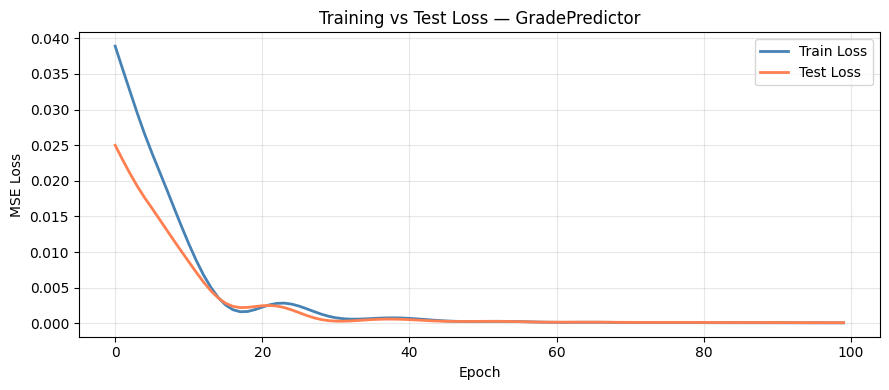

In [13]:
# --- Plot training vs test loss ---

plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  color='coral',     linewidth=2)
plt.title('Training vs Test Loss — GradePredictor')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=100)
plt.show()

# What to look for:
# Both curves going down = model is learning
# Test loss >> Train loss = overfitting (model memorised training data)
# Both curves flat early = learning rate too low or model too small

---
## Section 6 — model.train() vs model.eval()

In [14]:
# This trips everyone up at first

# model.train()  → enables Dropout, BatchNorm behaves as in training
# model.eval()   → disables Dropout, BatchNorm uses running stats

# For GradePredictor above it doesn't matter (no Dropout/BatchNorm)
# But it matters the moment you add them — so always follow the pattern

# Correct pattern:
# Training:   model.train() → forward → loss → backward → step
# Inference:  model.eval()  → with torch.no_grad(): → forward

# Demo with Dropout
class ModelWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear  = nn.Linear(4, 4)
        self.dropout = nn.Dropout(p=0.5)  # randomly zero 50% of neurons during training

    def forward(self, x):
        return self.dropout(self.linear(x))

m = ModelWithDropout()
x = torch.ones(1, 4)

m.train()
print("train() output (some zeros from dropout):", m(x))

m.eval()
print("eval() output (no dropout, consistent): ", m(x))

train() output (some zeros from dropout): tensor([[ 0.6244, -0.7770,  0.7811, -1.8386]], grad_fn=<MulBackward0>)
eval() output (no dropout, consistent):  tensor([[ 0.3122, -0.3885,  0.3906, -0.9193]], grad_fn=<AddmmBackward0>)


---
## Section 7 — Save and Load a Model

In [15]:
# Save — only saves weights (recommended)
torch.save(model.state_dict(), 'grade_predictor.pth')
print("Model saved to grade_predictor.pth")

# Load — create model structure first, then load weights
loaded_model = GradePredictor()
loaded_model.load_state_dict(torch.load('grade_predictor.pth', weights_only=True))
loaded_model.eval()
print("Model loaded successfully")

# Verify it gives the same output
with torch.no_grad():
    original_out = model(X_test[:3])
    loaded_out   = loaded_model(X_test[:3])

print("Original output:", original_out.squeeze().numpy().round(4))
print("Loaded output:  ", loaded_out.squeeze().numpy().round(4))
print("Match:", torch.allclose(original_out, loaded_out))

Model saved to grade_predictor.pth
Model loaded successfully
Original output: [0.5166 0.404  0.4266]
Loaded output:   [0.5166 0.404  0.4266]
Match: True


---
## Section 8 — Quick Reference Cheatsheet

In [16]:
# ================================================================
# nn.Module CHEATSHEET
# ================================================================

# DEFINE A MODEL
# class MyModel(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.layer = nn.Linear(in, out)
#     def forward(self, x):
#         return self.layer(x)

# COMMON LAYERS
# nn.Linear(in, out)         ← fully connected
# nn.ReLU()                  ← activation
# nn.Sigmoid()               ← binary output
# nn.Dropout(p=0.5)          ← regularization
# nn.BatchNorm1d(features)   ← normalize activations
# nn.Embedding(vocab, dim)   ← for text/tokens

# LOSS FUNCTIONS
# nn.MSELoss()               ← regression
# nn.BCELoss()               ← binary classification
# nn.CrossEntropyLoss()      ← multi-class classification

# OPTIMIZERS
# optim.Adam(model.parameters(), lr=0.001)     ← default choice
# optim.AdamW(model.parameters(), lr=0.001)    ← for transformers
# optim.SGD(model.parameters(), lr=0.01)       ← simple baseline

# TRAINING LOOP (memorise this)
# model.train()
# optimizer.zero_grad()
# output = model(x)
# loss = criterion(output, target)
# loss.backward()
# optimizer.step()

# INFERENCE
# model.eval()
# with torch.no_grad():
#     output = model(x)

# SAVE / LOAD
# torch.save(model.state_dict(), 'model.pth')
# model.load_state_dict(torch.load('model.pth', weights_only=True))

# INSPECT
# model.parameters()                          ← all weights
# sum(p.numel() for p in model.parameters())  ← total param count
# model.state_dict()                          ← all weights as dict

print("Cheatsheet loaded.")

Cheatsheet loaded.


---
## ✅ Proof Checklist

- [ ] Defined a neural network by subclassing `nn.Module`
- [ ] Implemented `__init__` and `forward` correctly
- [ ] Ran a forward pass with a single sample and a batch
- [ ] Counted total parameters with `sum(p.numel()...)`
- [ ] Used at least 3 activation functions and explained when to use each
- [ ] Built a model with `nn.Sequential`
- [ ] Picked the right loss function for a regression task
- [ ] Ran the full training loop (zero → forward → loss → backward → step)
- [ ] Used `model.train()` and `model.eval()` correctly
- [ ] Plotted training vs test loss curve
- [ ] Saved and loaded model weights with `state_dict`

**Next skill:** DataLoader & Datasets — feeding real data into your model (`04_dataloader.ipynb`)